In [10]:
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
import lightgbm as lgb

import os
import sys
root_path="/home/iaw/DATA2/AAReact/src"
sys.path.append(root_path)
from util.RegressMetrics import r2_score, mse_score, mae_score, rmse_score
from util.train_tools import build_model, search_parms, split_data, load_data, eval_dataset_split
from tool.analysis import draw_pred_result

import seaborn as sns
from matplotlib import pyplot as plt

from typing import List, Tuple
from rich.table import Table
from rich import print as rp
from rich.progress import track
import shap
import pickle

from joblib import dump, load
from copy import deepcopy

from joblib import dump

In [ ]:
seed = 1
test_size = 0.2
# 超参之后的参数
xgb_best_params = {
      "colsample_bytree": 0.9
    , "learning_rate": 0.1
    , "max_depth": 8
    , "min_child_weight": 5
    , "n_estimators": 50
    , "reg_alpha": 0.5
    , "reg_lambda": 1.5
    , "subsample": 0.8
}


In [ ]:
# 模型初始训练数据
prefix1 = "/home/iaw/DATA2/AAReact/DataSet/Data_All/4_data_for_train/rdkit_xtb/train_test"
data_x, data_y, x_label, data_class = load_data(
    "{}_data_x.npy".format(prefix1), 
    "{}_data_y.npy".format(prefix1), 
    "{}_x_label.pkl".format(prefix1), 
    "{}_data_class.pkl".format(prefix1)
)


In [8]:
# 数据集外验证集
prefix2 = "/home/iaw/DATA2/AAReact/DataSet/Data_All/4_data_for_train/rdkit_xtb/extra"
data_x_new, data_y_new, x_label_new, data_class_new, data_name_new, data_batch_new = load_data(
    "{}_data_x.npy".format(prefix2), 
    "{}_data_y.npy".format(prefix2), 
    "{}_x_label.pkl".format(prefix2), 
    "{}_data_class.pkl".format(prefix2),
    "{}_data_name.pkl".format(prefix2),
    "{}_data_batch.pkl".format(prefix2)
)


# 这里需要对data_batch进行一次矫正
- extra 一共28个数据点
- 前6个是一组, 紧接着的6个也是一组, 随后的8个为两组, 均是CAT-71对应的不同的温度, 然后是4个CAT-72的, 4个CAT-73的

In [9]:
correction_batch = [
    # 第1组：6个，编号 3 CAT-41 new_rea
    3, 3, 3, 3, 3, 3,    
    # 第2组：6个，编号 4 CAT-42 new_rea
    4, 4, 4, 4, 4, 4,
    # 第3组：8个（两组），编号 5、6 CAT-71 TEMP
    5, 5, 5, 5, 6, 6, 6, 6,
    # 第4组：4个，CAT-72，编号 7    CAT-72
    7, 7, 7, 7,
    # 第5组：4个，CAT-73，编号 8    CAT-73
    8, 8, 8, 8
]
assert len(correction_batch) == len(data_batch_new), "Error[iaw]: len(correction_batch) = len(data_batch_new)"
data_batch_new = correction_batch

In [60]:
print("AddDataBatch, test0, extra_test0, test1, extra_test1")
for add_data_batch in [5, 6, 7, 8]:
    add_data_idx = []
    extra_test_data_idx = []
    for i, i_t in enumerate(data_batch_new):
        if i_t == add_data_batch:
            add_data_idx.append(i)
        else:
            extra_test_data_idx.append(i)


    data_x_iter0 = deepcopy(data_x)
    data_y_iter0 = deepcopy(data_y)
    data_class_iter0 = deepcopy(data_class)

    X_train_iter0, X_test_iter0, y_train_iter0, y_test_iter0,  class_train_iter0, class_test_iter0 = train_test_split(
        data_x_iter0,        
        data_y_iter0,
        data_class_iter0,
        test_size=test_size,
        random_state=seed, 
    )

    # old tain + new train
    X_train_iter1 = np.vstack([X_train_iter0, data_x_new[add_data_idx,:]])
    y_train_iter1 = np.hstack([y_train_iter0, data_y_new[add_data_idx]])
    class_train_iter1 = deepcopy(class_train_iter0)
    for i in add_data_idx:
        class_train_iter1.append(data_class_new[i])
    
    # new train
    #X_train_iter1 = data_x_new[add_data_idx,:]
    #y_train_iter1 = data_y_new[add_data_idx]
    #class_train_iter1 = []
    #for i in add_data_idx:
    #    class_train_iter1.append(data_class_new[i])

    # 抛开额外新加入train的数据, 作为extra_test
    extra_X_test_iter0 = deepcopy(data_x_new[extra_test_data_idx,:])
    extra_y_test_iter0 = deepcopy(data_y_new[extra_test_data_idx])
    extra_class_test_iter0 = []
    for i in extra_test_data_idx:
        extra_class_test_iter0.append(data_class_new[i])

    # 加载训练好的模型
    model_iter0 = load("/home/iaw/DATA2/AAReact/train/output/pt/xgb_rdkit_xtb_seed_0-1_test_0-2.pkl")
    
    # 训练新的模型
    #model_iter1 = deepcopy(model_iter0)
    #model_iter1.set_params(learning_rate=0.01, n_estimators=70)      # 降低学习率
    #model_iter1.fit(X_train_iter1, y_train_iter1, xgb_model=model_iter0)
    model_iter1 = build_model("xgb", seed, n_cpu = -1)
    model_iter1.set_params(**xgb_best_params)
    model_iter1.fit(X_train_iter1, y_train_iter1)
    # 在本地保存
    dump(model_iter1, "./pt/iter1_add-data-batch_{}.pkl".format(add_data_batch))

    # predict -> test0
    test_pred_iter0 = model_iter0.predict(X_test_iter0)
    extra_test_pred_iter0 = model_iter0.predict(extra_X_test_iter0)

    # predict -> test1
    test_pred_iter1 = model_iter1.predict(X_test_iter0)
    extra_test_pred_iter1 = model_iter1.predict(extra_X_test_iter0)

    print("{}, {:.4f}, {:.4f}, {:.4f}, {:.4f}".format(add_data_batch
          , r2_score(y_pred = test_pred_iter0, y_true = y_test_iter0)
          , r2_score(y_pred = extra_test_pred_iter0, y_true = extra_y_test_iter0)
          , r2_score(y_pred = test_pred_iter1, y_true = y_test_iter0)
          , r2_score(y_pred = extra_test_pred_iter1, y_true = extra_y_test_iter0)))

AddDataBatch, test0, extra_test0, test1, extra_test1
5, 0.8387, 0.6907, 0.8175, 0.8476
6, 0.8387, 0.7509, 0.8113, 0.8562
7, 0.8387, 0.5728, 0.8364, 0.4843
8, 0.8387, 0.6468, 0.8395, 0.4905


In [61]:
model_iter0.get_params()["n_estimators"]

50

In [62]:
model_iter1.get_params()["n_estimators"]

50

In [65]:
extra_y_test_iter0

array([-0.89  , -0.85  , -0.76  , -0.84  , -0.86  , -0.769 ,  0.93  ,
        0.93  ,  0.9   ,  0.92  ,  0.92  ,  0.87  ,  0.8   ,  0.0678,
        0.223 ,  0.38  ,  0.82  ,  0.0064,  0.775 ,  0.793 , -0.33  ,
       -0.6241, -0.327 , -0.137 ])

In [63]:
model_iter0.predict(extra_X_test_iter0)

array([-0.6647187 , -0.7962694 , -0.78373754, -0.78373754, -0.78923357,
       -0.78373754,  0.75003195,  0.8154292 ,  0.82074845,  0.82074845,
        0.82074845,  0.82074845,  0.12935548, -0.01200717, -0.37557963,
       -0.39243108,  0.11555902, -0.08631863, -0.15796483, -0.19370204,
       -0.16345002, -0.16831681,  0.04154958, -0.02181706], dtype=float32)

In [64]:
model_iter1.predict(extra_X_test_iter0)

array([-0.6715794 , -0.8026276 , -0.8026276 , -0.8026276 , -0.8026276 ,
       -0.8026276 ,  0.7420505 ,  0.828649  ,  0.828649  ,  0.828649  ,
        0.828649  ,  0.828649  , -0.0283516 , -0.20387602, -0.5170409 ,
       -0.46859273, -0.06433215, -0.2432085 , -0.3430624 , -0.304889  ,
       -0.0546318 , -0.03870507,  0.17157087,  0.09650261], dtype=float32)

In [58]:
print("AddDataBatch, test0, extra_test0, test1, extra_test1")
for add_data_batch in [5, 6, 7, 8]:
    add_data_idx = []
    extra_test_data_idx = []
    for i, i_t in enumerate(data_batch_new):
        if i_t == add_data_batch:
            add_data_idx.append(i)
        else:
            extra_test_data_idx.append(i)

    data_x_iter0 = deepcopy(data_x)
    data_y_iter0 = deepcopy(data_y)
    data_class_iter0 = deepcopy(data_class)

    X_train_iter0, X_test_iter0, y_train_iter0, y_test_iter0, class_train_iter0, class_test_iter0 = train_test_split(
        data_x_iter0,
        data_y_iter0,
        data_class_iter0,
        test_size=test_size,
        random_state=seed,
    )

    # ===================== 核心：旧数据 + 新数据 加权训练 =====================
    X_extra = data_x_new[add_data_idx,:]
    y_extra = data_y_new[add_data_idx]

    # 合并：原训练数据 + 新的少量extra数据
    X_mix = np.concatenate([X_train_iter0, X_extra])
    y_mix = np.concatenate([y_train_iter0, y_extra])

    # 给 extra 数据 更高权重（重点学习）
    weight_old = np.ones(len(X_train_iter0))   # 旧数据权重 1
    weight_new = np.ones(len(X_extra)) * 2     # 新数据权重 5（可以调 3~10）
    sample_weight = np.concatenate([weight_old, weight_new])

    # ===================== 加载最优参数，重新训练 =====================
    model_iter1 = build_model("xgb", seed, n_cpu=-1)
    model_iter1.set_params(**xgb_best_params)  # 用你之前调好的最佳超参！

    # 带权重训练（100% 会改变结果！）
    model_iter1.fit(X_mix, y_mix, sample_weight=sample_weight)

    # ===================== 预测 =====================
    test_pred_iter0 = model_iter0.predict(X_test_iter0)
    extra_test_pred_iter0 = model_iter0.predict(extra_X_test_iter0)
    test_pred_iter1 = model_iter1.predict(X_test_iter0)
    extra_test_pred_iter1 = model_iter1.predict(extra_X_test_iter0)

    print("{}, {:.4f}, {:.4f}, {:.4f}, {:.4f}".format(add_data_batch
          , r2_score(test_pred_iter0, y_test_iter0)
          , r2_score(extra_test_pred_iter0, extra_y_test_iter0)
          , r2_score(test_pred_iter1, y_test_iter0)
          , r2_score(extra_test_pred_iter1, extra_y_test_iter0)))

AddDataBatch, test0, extra_test0, test1, extra_test1
5, 0.7634, 0.4561, 0.7511, 0.8871
6, 0.7634, 0.4561, 0.7197, 0.8849
7, 0.7634, 0.4561, 0.7447, 0.4593
8, 0.7634, 0.4561, 0.7505, 0.2269


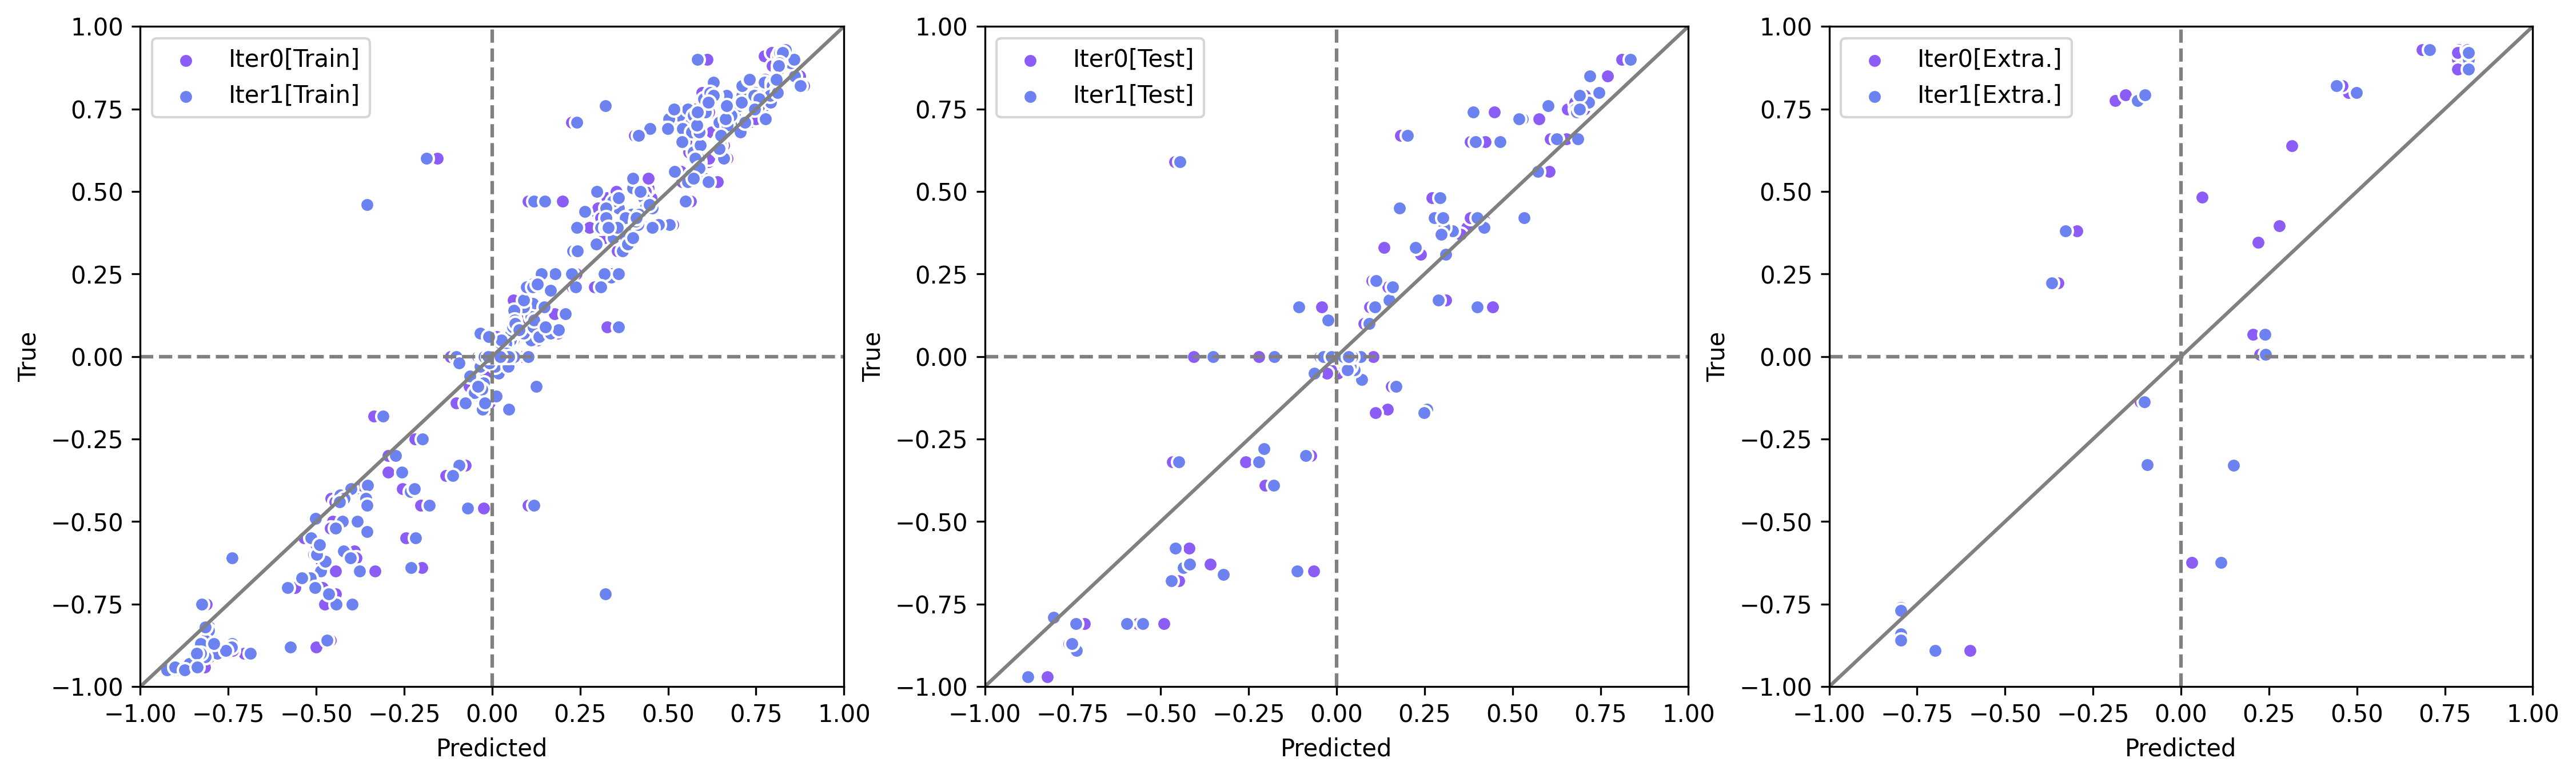

In [52]:
#color_s = ["gray", "#8b5cf6", "#d4d818", "#60f43f", "#d45a5a"]
#fig, ax = plt.subplots(1, 3, figsize = (18, 5), dpi = 300)
#
#ax[0].scatter(train_pred_iter0, y_train_iter0, label = "Iter0[Train]", c = "#8b5cf6", alpha = 1, edgecolors = "white")
#ax[0].scatter(train_pred_iter1, y_train_iter0, label = "Iter1[Train]", c = "#6c82f1", alpha = 1, edgecolors = "white")
#ax[0].plot([-1, 1], [-1, 1], c = "gray")
#ax[0].plot([0, 0], [-1, 1], c = "gray", linestyle = "--")
#ax[0].plot([-1, 1], [0, 0], c = "gray", linestyle = "--")
#ax[0].set_xlim([-1, 1])
#ax[0].set_ylim([-1, 1])
#ax[0].set_xlabel("Predicted")
#ax[0].set_ylabel("True")
#ax[0].legend()
#
#ax[1].scatter(test_pred_iter0, y_test_iter0, label = "Iter0[Test]", c = "#8b5cf6", alpha = 1, edgecolors = "white")
#ax[1].scatter(test_pred_iter1, y_test_iter0, label = "Iter1[Test]", c = "#6c82f1", alpha = 1, edgecolors = "white")
#ax[1].plot([-1, 1], [-1, 1], c = "gray")
#ax[1].plot([0, 0], [-1, 1], c = "gray", linestyle = "--")
#ax[1].plot([-1, 1], [0, 0], c = "gray", linestyle = "--")
#ax[1].set_xlim([-1, 1])
#ax[1].set_ylim([-1, 1])
#ax[1].set_xlabel("Predicted")
#ax[1].set_ylabel("True")
#ax[1].legend()
#
#ax[2].scatter(extra_test_pred_iter0, extra_y_test_iter0, label = "Iter0[Extra.]", c = "#8b5cf6", alpha = 1, edgecolors = "white")
#ax[2].scatter(extra_test_pred_iter1, extra_y_test_iter1, label = "Iter1[Extra.]", c = "#6c82f1", alpha = 1, edgecolors = "white")
#ax[2].plot([-1, 1], [-1, 1], c = "gray")
#ax[2].plot([0, 0], [-1, 1], c = "gray", linestyle = "--")
#ax[2].plot([-1, 1], [0, 0], c = "gray", linestyle = "--")
#ax[2].set_xlim([-1, 1])
#ax[2].set_ylim([-1, 1])
#ax[2].set_xlabel("Predicted")
#ax[2].set_ylabel("True")
#ax[2].legend()
#

In [55]:
#data_x_cli = np.load("/home/iaw/DATA2/AAReact/test/iter_1/xgb_rdkit_soap_xtb-REA-5_SOL-2_CAT-41_T60_P20.npy")
#data_x_gui = data_x_new[0, :]
#print("Shape, cli == gui: {}".format(data_x_cli.shape == data_x_gui.shape))
#print("Value, cli == gui: {}".format(np.allclose(data_x_cli, data_x_gui)))
#x_label_gui = x_label_new["label1_rdkit"] + x_label_new["label2_soap"] + x_label_new["label3_xtb"]
#x_label_cli = x_label["label1_rdkit"] + x_label["label2_soap"] + x_label["label3_xtb"]
#print("Label, cli == gui: {}".format(x_label_cli == x_label_gui))
#
#for i in range(data_x_cli.shape[0]):
#    if not np.allclose(data_x_cli[i], data_x_gui[i]):
#        print(x_label_cli[i], data_x_cli[i], data_x_gui[i])
#    #else:
#    #    print(x_label_cli[i], data_x_cli[i], data_x_gui[i])